# Proyecto 2: Detección de Lavado de Dinero

## 0. Setup

In [54]:
import os, sys, gc, glob, json, math, re, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.rcParams["figure.figsize"] = (10, 4)

# Find data if working in Colab or Kaggle
IN_COLAB = "google.colab" in sys.modules
IN_KAGGLE = os.path.isdir("/kaggle/input")
OUT_DIR = ("/kaggle/working/aml_outputs" if IN_KAGGLE else "/content/aml_outputs" if IN_COLAB else "./aml_outputs")
os.makedirs(OUT_DIR, exist_ok=True)
print("Colab:", IN_COLAB, "| Kaggle:", IN_KAGGLE, "| outputs ->", OUT_DIR)

Colab: False | Kaggle: False | outputs -> ./aml_outputs


**Dataset.** IBM AML *HI-Small*

Simula bancos, personas y empresas donde el lavado se inyecta con topologías conocidas. Este se utiliza como dataset principal en lugar de PaySim ya que se presta más a la arquitectura planeada para el proyecto (feature engineering inicial, modelos utilizando secuencias, etc.) dadas las topologías más complejas y emisores repetidos.

In [55]:
DATASET = "ealtman2019/ibm-transactions-for-anti-money-laundering-aml"
FILES = ["HI-Small_Trans.csv", "HI-Small_Patterns.txt"]

def find_under(root, name):
    hits = glob.glob(os.path.join(root, "**", name), recursive=True)
    return hits[0] if hits else None

paths = {}
if os.environ.get("AML_DATA_DIR"):                 # local copy
    for f in FILES:
        paths[f] = find_under(os.environ["AML_DATA_DIR"], f)
elif IN_KAGGLE:                                    # dataset attached as input
    for f in FILES:
        paths[f] = find_under("/kaggle/input", f)
else:                                              # Colab: download single files only
    try:
        import kagglehub
    except ImportError:
        raise RuntimeError("Run: !pip install -q kagglehub")
    for f in FILES:
        try:
            p = kagglehub.dataset_download(DATASET, path=f)      # single file, not the whole dataset
        except TypeError:
            raise RuntimeError("Old kagglehub without single-file download. Run: !pip install -q -U kagglehub, "
                               "then Runtime -> Restart session")
        paths[f] = p if os.path.isfile(p) else find_under(p, f)

for f, p in paths.items():
    assert p and os.path.isfile(p), f"Could not find {f}"
    print(f"{f}: {os.path.getsize(p) / 1e6:,.0f} MB")
TRANS_PATH, PATTERNS_PATH = paths[FILES[0]], paths[FILES[1]]
print(elapsed())

HI-Small_Trans.csv: 476 MB
HI-Small_Patterns.txt: 0 MB
[98.0 min]


## 1. Primer vistazo

In [56]:

# Hay 2 columnas con el nombre account, se soluciona cargando nombres y tipos de columna
# de antemano antes de leer el dataset
COLS = ["ts", "from_bank", "from_acct", "to_bank", "to_acct", "amt_received", "recv_currency",
        "amt_paid", "pay_currency", "pay_format", "is_laundering"]
DTYPES = {"ts": "string", "from_bank": "int64", "from_acct": "string", "to_bank": "int64",
          "to_acct": "string", "amt_received": "float64", "recv_currency": "category",
          "amt_paid": "float64", "pay_currency": "category", "pay_format": "category",
          "is_laundering": "int8"}

with open(TRANS_PATH) as f:                      # raw header: note the two columns named "Account"
    for _ in range(3):
        print(f.readline().rstrip())

df = pd.read_csv(TRANS_PATH, names=COLS, header=0, dtype=DTYPES)
df["ts"] = pd.to_datetime(df["ts"], format="%Y/%m/%d %H:%M")
df = df.sort_values("ts", kind="stable").reset_index(drop=True)
df["tx_id"] = np.arange(len(df), dtype=np.int64)

n_pos = int(df.is_laundering.sum())
print(f"\nRows: {len(df):,} | columns with nulls: {df.columns[df.isna().any()].tolist() or 'none'}")
print(f"Time range: {df.ts.min()} -> {df.ts.max()}")
print(f"Laundering transactions: {n_pos:,} ({n_pos / len(df):.4%}), about 1 in {len(df) // n_pos:,} {elapsed()}")
display(df.head())

Timestamp,From Bank,Account,To Bank,Account,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
2022/09/01 00:20,010,8000EBD30,010,8000EBD30,3697.34,US Dollar,3697.34,US Dollar,Reinvestment,0
2022/09/01 00:20,03208,8000F4580,001,8000F5340,0.01,US Dollar,0.01,US Dollar,Cheque,0

Rows: 5,078,345 | columns with nulls: none
Time range: 2022-09-01 00:00:00 -> 2022-09-18 16:18:00
Laundering transactions: 5,177 (0.1019%), about 1 in 980 [98.0 min]


,ts,from_bank,from_acct,to_bank,to_acct,amt_received,recv_currency,amt_paid,pay_currency,pay_format,is_laundering,tx_id
0,2022-09-01,3209,8000F4670,3209,8000F4670,"14,675.5700",US Dollar,"14,675.5700",US Dollar,Reinvestment,0,0
1,2022-09-01,1420,8005DFEB0,1420,8005DFEB0,897.3700,US Dollar,897.3700,US Dollar,Reinvestment,0,1
2,2022-09-01,10,8000F6850,10,8000F6850,"99,986.9400",US Dollar,"99,986.9400",US Dollar,Reinvestment,0,2
3,2022-09-01,12,8001167D0,12,8001167D0,16.0800,US Dollar,16.0800,US Dollar,Reinvestment,0,3
4,2022-09-01,1,8001364A0,1,8001364A0,10.3000,US Dollar,10.3000,US Dollar,Reinvestment,0,4


**Hallazgos**

- 5,078,345 transacciones en ~18 días de Septiembre de 2022.
- No hay valores nulos.
- 5,177 son lavado, **0.10% o ~1 de cada 980**.

**Decisiones**

La métrica de *Accuracy* resultaría práctiocamente inútil, las métricas a utilizar deberían estar basadas en precision/recall. 

## 2. ¿Quién es un emisor?

In [57]:
same_id_diff_bank = (df.groupby("from_acct", observed=True)["from_bank"].nunique() > 1).sum()
print(f"Account ids that appear under more than one bank: {same_id_diff_bank:,}")
print(f"Transactions where sender == receiver (same bank and account): "
      f"{((df.from_bank == df.to_bank) & (df.from_acct == df.to_acct)).mean():.2%}")

Account ids that appear under more than one bank: 4
Transactions where sender == receiver (same bank and account): 11.64%


**Hallazgos**

- El id de cuenta solo tiene sentido junto con su banco (4 id's aparecen con bancos distintos).
- ~11.6% de las transacciones van de una cuenta a sí misma.

**Decisiones**

Una cuenta se identifica por `bank_account`. Codificamos cuentas como enteros para ahorrar memoria y guardamos una tabla de nombres para el MVP. Las auto-transferencias se mantienen y se marcan con un feature en vez de eliminarse.

In [58]:
n = len(df)
sender_str = df["from_bank"].astype(str) + "_" + df["from_acct"].astype(str)
receiver_str = df["to_bank"].astype(str) + "_" + df["to_acct"].astype(str)
codes, uniques = pd.factorize(pd.concat([sender_str, receiver_str], ignore_index=True))
ACCOUNT_NAMES = np.asarray(uniques, dtype=object)
df["sender"] = codes[:n].astype(np.int32)
df["receiver"] = codes[n:].astype(np.int32)
df["is_self"] = (df["sender"] == df["receiver"]).astype(np.float32)
df["same_bank"] = (df["from_bank"] == df["to_bank"]).astype(np.float32)
del sender_str, receiver_str, codes, uniques
print(f"Accounts: {len(ACCOUNT_NAMES):,} | senders: {df.sender.nunique():,} {elapsed()}")

Accounts: 515,088 | senders: 496,999 [98.1 min]


## 3. Monedas y montos

In [59]:
display(df["pay_currency"].value_counts().to_frame("transactions"))
cross = df["pay_currency"].astype(str).to_numpy() != df["recv_currency"].astype(str).to_numpy()
print(f"Cross-currency transactions: {cross.mean():.2%}")

,transactions
pay_currency,
US Dollar,1895172
Euro,1168297
Swiss Franc,234860
Yuan,213752
Shekel,192184
Rupee,190202
UK Pound,180738
Yen,155209
Ruble,155178


Cross-currency transactions: 1.42%


**Hallazgos**

- 15 monedas; Dólar (1.9M) y Euro (1.2M) dominan, y Bitcoin es una de ellas.
- Solo el 1.42% de las transacciones cambian de moneda, pero esas filas revelan el tipo de cambio que usa el
  simulador (monto recibido / monto pagado).
- Los montos crudos no son comparables entre monedas.

**Decisiones**

Convertimos todo a USD usando la tasa mediana implícita en las transacciones cross-currency pagadas en cada moneda y recibidas en USD. Las filas sin tasa se descartarían (en la práctica no hay ninguna). Se guarda una bandera de cross-currency como feature.

In [60]:
USD = "US Dollar"
pay_cur = df["pay_currency"].astype(str).to_numpy()
recv_cur = df["recv_currency"].astype(str).to_numpy()
to_usd = cross & (recv_cur == USD)
rates = (pd.Series(df["amt_received"].to_numpy()[to_usd] / df["amt_paid"].to_numpy()[to_usd])
           .groupby(pay_cur[to_usd]).median())
rates[USD] = 1.0
missing = sorted(set(np.unique(pay_cur)) - set(rates.index))
print("Currencies without a USD rate (rows dropped):", missing or "none")
df["amt_usd"] = df["amt_paid"].to_numpy() * pd.Series(pay_cur).map(rates).to_numpy()
df["is_cross_currency"] = cross.astype(np.float32)
df = df[df["amt_usd"].notna()].reset_index(drop=True)
display(rates.sort_values().to_frame("to_usd"))
del pay_cur, recv_cur, cross, to_usd

Currencies without a USD rate (rows dropped): none


,to_usd
Yen,0.0095
Ruble,0.0129
Rupee,0.0136
Mexican Peso,0.0473
Yuan,0.1493
Brazil Real,0.1771
Saudi Riyal,0.2666
Shekel,0.2961
Australian Dollar,0.7078
Canadian Dollar,0.7580


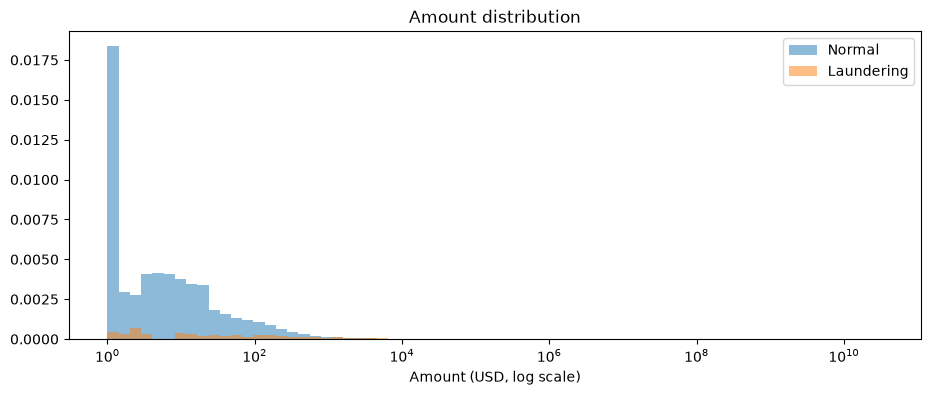

,count,mean,std,min,25%,50%,75%,99%,max
is_laundering,,,,,,,,,
0,"5,073,168.0000","346,030.8567","23,233,414.7798",0.0001,158.0000,891.0500,"5,273.8331","3,099,715.3200","26,558,613,301.7214"
1,"5,177.0000","5,169,483.6401","231,331,481.7001",0.3867,"2,160.5600","5,878.8063","13,758.5029","15,793,198.1262","16,297,043,812.7494"


In [61]:
x_all = df["amt_usd"].clip(lower=1)
bins = np.logspace(0, np.log10(x_all.max()) + 0.1, 70)
fig, ax = plt.subplots(figsize=(11, 4))
for label, name in [(0, "Normal"), (1, "Laundering")]:
    ax.hist(df.loc[df.is_laundering == label, "amt_usd"].clip(lower=1), bins=bins, density=True, alpha=0.5, label=name)
ax.set_xscale("log"); ax.set_xlabel("Amount (USD, log scale)"); ax.set_title("Amount distribution"); ax.legend()
plt.show()
display(df.groupby("is_laundering")["amt_usd"].describe(percentiles=[.25, .5, .75, .99]))

**Hallazgos**

- Los montos abarcan ~14 órdenes de magnitud (de 0.0001 a 2.6×10¹⁰ USD).
- Los montos de lavado suelen ser mayores (mediana ≈ 5,879 USD vs 891 USD en transacciones normales), pero las se traslapan mucho, así que el monto solo no separa las clases.

**Decisiones**

Usamos `log(1 + monto)` para que los valores extremos no dominen, más el monto **relativo al monto típico del propio emisor** en la secuencia ("inusualmente grande para esta persona").

## 4. Tiempo

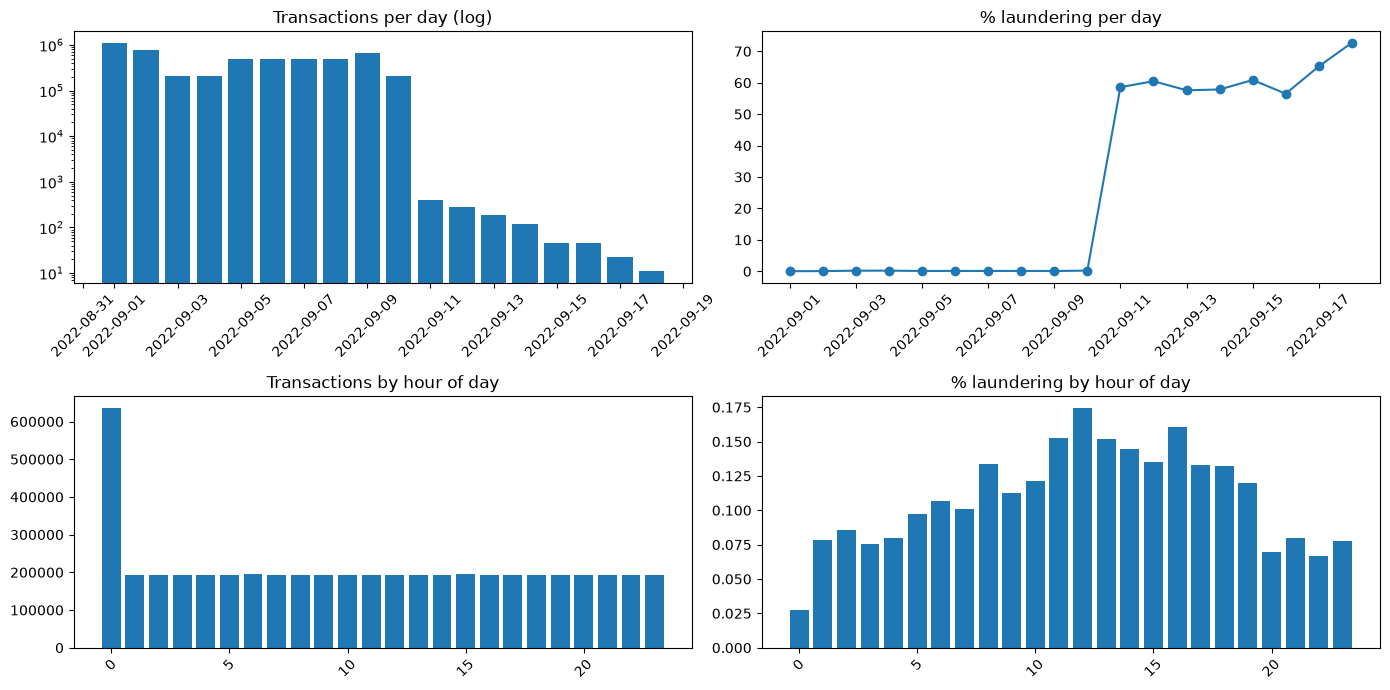

,size,mean
ts,,
2022-09-01,1114921,0.0003
2022-09-02,754449,0.0005
2022-09-03,207382,0.0019
2022-09-04,207430,0.0020
2022-09-05,482650,0.0010
2022-09-06,482089,0.0011
2022-09-07,482751,0.0010
2022-09-08,482773,0.0011
2022-09-09,654467,0.0008


In [62]:
daily = df.set_index("ts").resample("D")["is_laundering"].agg(["size", "mean"])
hourly = df.groupby(df.ts.dt.hour)["is_laundering"].agg(["size", "mean"])
fig, ax = plt.subplots(2, 2, figsize=(14, 7))
ax[0, 0].bar(daily.index, daily["size"]); ax[0, 0].set_yscale("log"); ax[0, 0].set_title("Transactions per day (log)")
ax[0, 1].plot(daily.index, daily["mean"] * 100, marker="o"); ax[0, 1].set_title("% laundering per day")
ax[1, 0].bar(hourly.index, hourly["size"]); ax[1, 0].set_title("Transactions by hour of day")
ax[1, 1].bar(hourly.index, hourly["mean"] * 100); ax[1, 1].set_title("% laundering by hour of day")
for a in ax.flat:
    a.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()
display(daily)

**Qué encontramos**

- La actividad normal se detiene después del 2022-09-10. Del 09-11 al 09-18 solo hay ~1,100 transacciones, y ~60% son lavado. El simulador sigue corriendo intentos de lavado que ya estaban en curso
  después de que el resto de la economía se detiene.
- El día 1 tiene ~1.1M transacciones y algunos días ~200k: es scheduling del simulador, no comportamiento real.
- La hora 0 tiene ~630k transacciones vs ~190k en cualquier otra hora, y la tasa de lavado más baja.

Dos chequeos de seguimiento. Xuánto lavado vive solo en la cola, y qué es el pico de medianoche.

In [63]:
TAIL_START = "2022-09-11"
tail = df["ts"] >= pd.Timestamp(TAIL_START)
laund = df["is_laundering"] == 1
pre_senders = set(df.loc[~tail & laund, "sender"].unique())
tail_senders = set(df.loc[tail & laund, "sender"].unique())
print(f"Tail transactions: {int(tail.sum()):,} ({df.loc[tail, 'is_laundering'].mean():.1%} laundering)")
print(f"Laundering tx in tail: {int((tail & laund).sum()):,} of {int(laund.sum()):,} "
      f"({(tail & laund).sum() / laund.sum():.1%})")
print(f"Positive senders whose laundering happens ONLY in the tail: {len(tail_senders - pre_senders):,} "
      f"of {len(pre_senders | tail_senders):,}")

hour = df["ts"].dt.hour
at_midnight = (hour == 0) & (df["ts"].dt.minute == 0)
print(f"\nHour-0 transactions: {int((hour == 0).sum()):,}, of which exactly 00:00: {at_midnight[hour == 0].mean():.1%}")
print(f"Laundering rate at 00:00: {df.loc[at_midnight, 'is_laundering'].mean():.4%} | "
      f"rest of the day: {df.loc[~at_midnight, 'is_laundering'].mean():.4%}")
display(pd.DataFrame({"share at 00:00": df.loc[at_midnight, "pay_format"].value_counts(normalize=True),
                      "share overall": df["pay_format"].value_counts(normalize=True)}))
del tail, laund, hour, at_midnight

Tail transactions: 1,108 (59.1% laundering)
Laundering tx in tail: 655 of 5,177 (12.7%)
Positive senders whose laundering happens ONLY in the tail: 340 of 3,376

Hour-0 transactions: 634,726, of which exactly 00:00: 2.8%
Laundering rate at 00:00: 0.0166% | rest of the day: 0.1022%


,share at 00:00,share overall
pay_format,,
ACH,0.0507,0.1183
Bitcoin,0.0296,0.0288
Cash,0.0329,0.0967
Cheque,0.1193,0.3671
Credit Card,0.3238,0.2606
Reinvestment,0.4282,0.0947
Wire,0.0156,0.0338


**Hallazgos**

- La cola tiene 1,108 transacciones, 59% lavado: **655 transacciones de lavado (12.7% del total)**.
- **340 de los 3,376 emisores positivos (10%) lavan solo en la cola.** Si se descartara la cola, se perderían.
- **El pico de medianoche no es un batch de medianoche.** La hora 0 tiene 634,726 transacciones, pero solo 2.8%
  están marcadas exactamente 00:00; el resto se reparte en la hora. Las pocas transacciones de las 00:00 son 43%
  Reinvestment (9% en general) y tienen tasa de lavado de 0.017% vs 0.10% el resto del día.
- Los volúmenes diarios saltan entre niveles fijos (1.1M, 750k, 480k, 207k) y la tasa de lavado por hora sigue la
  misma forma. La hora del día en este dataset refleja cómo programa actividad el simulador.

**Decisiones**

**Mantenemos la cola, pero nunca le damos tiempo absoluto al modelo.** Sin fechas, índices de día ni "días desde
el inicio", solo el gap desde la transacción previa del emisor. El split se estratifica por presencia en la
cola, y después de modelar revisamos si los positivos de la cola se detectan sospechosamente más que el resto.

**Descartamos hora del día por completo, incluyendo la bandera de medianoche.** Una versión anterior tenía un
flag `is_midnight` y features de hora del día. El chequeo de arriba muestra que la bandera describía casi nada
(2.8% de la hora 0) y que el patrón horario es un artefacto del simulador.

## 5. Formatos de pago

In [64]:
fmt_tbl = (df.groupby("pay_format", observed=True)
             .agg(transactions=("tx_id", "size"), laundering=("is_laundering", "sum"), self_share=("is_self", "mean")))
fmt_tbl["laundering rate"] = fmt_tbl["laundering"] / fmt_tbl["transactions"]
fmt_tbl["share of all laundering"] = fmt_tbl["laundering"] / fmt_tbl["laundering"].sum()
display(fmt_tbl.sort_values("laundering", ascending=False))

,transactions,laundering,self_share,laundering rate,share of all laundering
pay_format,,,,,
ACH,600797,4483,0.1188,0.0075,0.8659
Cheque,1864331,324,0.0033,0.0002,0.0626
Credit Card,1323324,206,0.0032,0.0002,0.0398
Cash,490891,108,0.0030,0.0002,0.0209
Bitcoin,146091,56,0.1801,0.0004,0.0108
Reinvestment,481056,0,1.0000,0.0000,0.0000
Wire,171855,0,0.0046,0.0000,0.0000


**Hallazgos**

- **ACH concentra 4,483 de las 5,177 transacciones de lavado (87%)**, una tasa de 0.75% vs ≤0.04% en el resto.
- **Wire (172k tx) y Reinvestment (481k tx) tienen cero lavado.** Reinvestment es casi todo auto-transferencias.

**Decisiones**

**Mantenemos ambos formatos en los datos**: forman parte del comportamiento real de cada emisor, y quitarlos
distorsionaría gaps y frecuencias. El modelo aprenderá que estos formatos se ven normales; eso es cierto aquí
pero puede no generalizar, y va en las limitaciones.

**Subsampleamos, solo en entrenamiento, emisores cuyas secuencias son puro Wire/Reinvestment.** Son negativos
garantizados y en su mayoría le enseñan al modelo una regla fácil. Validación y test conservan a todos los
emisores para que las métricas reflejen la distribución real.

In [65]:
WR_FORMATS = ["Wire", "Reinvestment"]
WR_ONLY_KEEP_FRAC = 0.20      # fraction of Wire/Reinvestment-only senders kept in the TRAINING split

## 6. Tipologías de lavado

In [66]:
# --- 2.3 Typologies from HI-Small_Patterns.txt (analysis only, never a model feature)
begin_re = re.compile(r"BEGIN LAUNDERING ATTEMPT\s*-\s*([A-Za-z\- ]+?)\s*(?::|$)")
rows, attempt_id, ptype = [], -1, None
with open(PATTERNS_PATH) as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        if line.startswith("BEGIN"):
            attempt_id += 1
            m = begin_re.match(line)
            ptype = m.group(1).strip().upper() if m else "UNKNOWN"
        elif line.startswith("END"):
            ptype = None
        elif ptype is not None:
            parts = line.split(",")
            if len(parts) == len(COLS):
                rows.append([attempt_id, ptype] + parts)

pat = pd.DataFrame(rows, columns=["attempt_id", "pattern"] + COLS)
pat["ts"] = pd.to_datetime(pat["ts"], format="%Y/%m/%d %H:%M")
pat["from_bank"] = pat["from_bank"].astype("int64")
pat["to_bank"] = pat["to_bank"].astype("int64")
pat["amt_paid"] = pat["amt_paid"].astype("float64").round(2)

KEYS = ["ts", "from_bank", "from_acct", "to_bank", "to_acct", "amt_paid"]
right = df.loc[df.is_laundering == 1, KEYS + ["tx_id"]].copy()
right["amt_paid"] = right["amt_paid"].round(2)
for t in (pat, right):
    t["from_acct"] = t["from_acct"].astype(str)
    t["to_acct"] = t["to_acct"].astype(str)
matched = pat.merge(right.drop_duplicates(KEYS), on=KEYS, how="left").dropna(subset=["tx_id"])
tx_pattern = matched.drop_duplicates("tx_id").set_index("tx_id")
df["pattern"] = df["tx_id"].map(tx_pattern["pattern"])
df["attempt_id"] = df["tx_id"].map(tx_pattern["attempt_id"])
print(f"Pattern tx parsed: {len(pat):,} | laundering tx with typology: "
      f"{df.loc[df.is_laundering == 1, 'pattern'].notna().mean():.1%}")

# drop raw string columns we no longer need (memory)
df = df.drop(columns=["from_acct", "to_acct", "amt_received", "recv_currency"])
del pat, right, matched, tx_pattern, rows
gc.collect()
print(f"Memory: {df.memory_usage(deep=True).sum() / 1e9:.2f} GB {elapsed()}")

Pattern tx parsed: 3,209 | laundering tx with typology: 62.0%
Memory: 0.44 GB [98.2 min]


In [67]:
display(df.loc[df.is_laundering == 1, "pattern"].fillna("(no typology)").value_counts().to_frame("laundering tx"))

,laundering tx
pattern,
(no typology),1968
GATHER-SCATTER,716
SCATTER-GATHER,626
STACK,466
FAN-OUT,342
FAN-IN,318
CYCLE,287
BIPARTITE,263
RANDOM,191


**Hallazgos**

- 8 tipologías (fan-out, fan-in, cycle, bipartite, stack, scatter-gather, gather-scatter, random), 40–54 intentos
  cada una; 100% de las transacciones del archivo de patrones calzan con el archivo principal.
- Solo **62% de las transacciones de lavado pertenecen a una tipología listada**; el resto es lavado sin patrón
  nombrado.
- Varias tipologías son patrones de grafo (ej. fan-in = muchos emisores → un receptor). Vistas desde la secuencia
  de un solo emisor, algunas se ven como una transacción ordinaria más.

**Decisiones**

Las tipologías **nunca se usan como features** (son etiquetas disfrazadas). Se usan después de modelar, para ver
qué patrones detecta cada stage y para conectar la atención con comportamientos de lavado conocidos en el
análisis de interpretabilidad. Que la vista por emisor no vea patrones del lado del receptor queda como
limitación explícita.

## 7. Historias de emisores y largo mínimo

Senders: 496,999 | positive senders (ever laundered): 3,376 (0.679%)


,count,mean,std,min,25%,50%,75%,90%,95%,99%,99.9%,max
transactions per sender,"496,999.0000",10.2180,290.2829,1.0000,1.0000,2.0000,5.0000,29.0000,46.0000,92.0000,159.0000,"168,672.0000"


,min length,% senders dropped,% transactions dropped,positive senders dropped,% positive senders dropped
0,1,0.0000,0.0000,0,0.0000
1,2,30.7353,3.0079,122,3.6137
2,3,62.5768,9.2404,618,18.3057
3,4,71.3669,11.8212,1291,38.2405
4,5,74.0887,12.8866,1750,51.8365
5,10,77.8655,15.2840,2191,64.8993
6,20,84.5406,24.4372,2489,73.7263


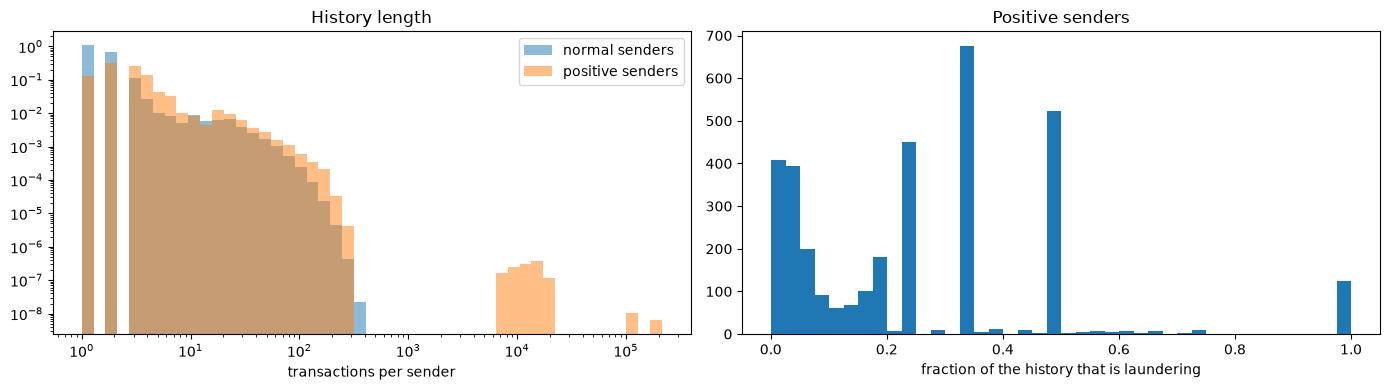

In [68]:
# order every sender's history chronologically; everything from here on relies on this order
df = df.sort_values(["sender", "ts", "tx_id"], kind="stable").reset_index(drop=True)
g = df.groupby("sender", sort=False)
sender_ntx = g["tx_id"].size()
sender_ever = g["is_laundering"].max()
counts = sender_ntx.to_numpy()
offsets = np.concatenate([[0], np.cumsum(counts)[:-1]])      # first row of each sender in df
assert (np.diff(df["sender"].to_numpy()) >= 0).all()

print(f"Senders: {len(counts):,} | positive senders (ever laundered): {int(sender_ever.sum()):,} "
      f"({sender_ever.mean():.3%})")
display(sender_ntx.describe(percentiles=[.25, .5, .75, .9, .95, .99, .999]).to_frame("transactions per sender").T)

rows = []
for k in [1, 2, 3, 4, 5, 10, 20]:
    short = counts < k
    rows.append({"min length": k, "% senders dropped": short.mean() * 100,
                 "% transactions dropped": counts[short].sum() / counts.sum() * 100,
                 "positive senders dropped": int(sender_ever.to_numpy()[short].sum()),
                 "% positive senders dropped": sender_ever.to_numpy()[short].sum() / sender_ever.sum() * 100})
display(pd.DataFrame(rows))

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
bins = np.logspace(0, np.log10(counts.max()) + 0.1, 50)
ax[0].hist(counts[sender_ever.to_numpy() == 0], bins=bins, density=True, alpha=0.5, label="normal senders")
ax[0].hist(counts[sender_ever.to_numpy() == 1], bins=bins, density=True, alpha=0.5, label="positive senders")
ax[0].set_xscale("log"); ax[0].set_yscale("log"); ax[0].legend()
ax[0].set_xlabel("transactions per sender"); ax[0].set_title("History length")
pos = sender_ever.to_numpy() == 1
ax[1].hist(g["is_laundering"].mean().to_numpy()[pos], bins=40)
ax[1].set_xlabel("fraction of the history that is laundering"); ax[1].set_title("Positive senders")
plt.tight_layout(); plt.show()

**Qué encontramos**

- 496,999 emisores; 3,376 lavan alguna vez (0.68%, ~1 de cada 147).
- **La mayoría de los emisores son muy cortos**: mediana 2 transacciones, percentil 75 en 5. Una cola larga llega
  hasta una cuenta con 168,672 transacciones.
- **Los emisores positivos son especialmente cortos.** Largo mínimo 3 descarta 618 emisores positivos (18%);
  largo mínimo 2 descarta solo 122 (3.6%) mientras quita el 31% de emisores con una sola transacción.
- En nuestra primera versión (mínimo 3) quedaban 185,993 emisores y 2,758 positivos.

**Qué hacemos al respecto**

**Largo mínimo 2.** Una sola transacción no tiene secuencia, no se
puede modelar como comportamiento en el tiempo. Desde dos transacciones ya hay al menos una relación entre
eventos. Bajar de 3 a 2 recupera ~500 emisores positivos (+18%), que importa mucho cuando los positivos son tan
escasos. Los emisores de una sola transacción quedan fuera del alcance de un modelo de secuencias y necesitarían
un modelo por transacción (limitación).

In [69]:
MIN_LEN = 2

## 8. Largo de ventana, stride y tope

Las secuencias son ventanas de largo fijo sobre la historia de cada emisor:

- Emisores con a lo más `L` transacciones dan **una** ventana (toda su historia).
- Emisores más largos dan ventanas solapadas: la primera termina en la transacción más reciente, cada siguiente
  empieza `stride` transacciones antes, y la última empieza en la primera transacción. Se guardan a lo más `cap`
  ventanas (las más recientes). Ejemplo con `L=32`, `stride=16`, 60 transacciones: ventanas de tx 29–60, 13–44,
  1–32.
- Cada ventana se etiqueta positiva si contiene una transacción de lavado.

En nuestra primera versión (`L=64`, `stride=32`, `cap=8`, largo mínimo 3) las ventanas solapadas casi no
importaban: agregaron 19k ventanas (205,280 vs 185,993 emisores) y recuperaron solo 30 emisores positivos, porque
solo ~2.6% de emisores tiene más de 64 transacciones. La tabla de abajo compara configuraciones antes de elegir.

In [70]:
def plan_windows(n_tx, L, stride, cap):
    """Window layout for senders with n_tx transactions.
    Returns per window: owner (index into n_tx), rank (0 = most recent), start index, length."""
    n_tx = np.asarray(n_tx, dtype=np.int64)
    over = np.maximum(n_tx - L, 0)                          # transactions beyond a single window
    k_full = over // stride + 1                             # windows anchored at the most recent tx
    extra = (over % stride != 0).astype(np.int64)           # plus one window starting at tx 0
    n_win = np.minimum(k_full + extra, cap)
    owner = np.repeat(np.arange(len(n_tx)), n_win)
    rank = np.arange(n_win.sum()) - np.repeat(np.cumsum(n_win) - n_win, n_win)
    start = np.where(rank < k_full[owner], over[owner] - rank * stride, 0)
    length = np.minimum(n_tx[owner], L)
    return owner, rank, start, length

# helpers computed once: laundering prefix sums and the last laundering position of each sender
laund_arr = df["is_laundering"].to_numpy().astype(np.int64)
laund_prefix = np.concatenate([[0], np.cumsum(laund_arr)])
pos_in_sender = np.arange(len(df)) - np.repeat(offsets, counts)
last_laund = np.full(len(counts), -1, dtype=np.int64)
lm = laund_arr == 1
np.maximum.at(last_laund, np.repeat(np.arange(len(counts)), counts)[lm], pos_in_sender[lm])
N_POS_TOTAL = int((last_laund >= 0).sum())

def describe_config(min_len, L, stride, cap, n_features=9):
    elig = np.flatnonzero(counts >= min_len)
    owner, rank, start, length = plan_windows(counts[elig], L, stride, cap)
    first_row = offsets[elig][owner] + start
    pos_windows = (laund_prefix[first_row + length] - laund_prefix[first_row]) > 0
    n_win = np.bincount(owner, minlength=len(elig))
    oldest_start = start[np.cumsum(n_win) - 1]               # windows overlap, so coverage = [oldest_start, end)
    covered = last_laund[elig] >= oldest_start
    return {"min len": min_len, "L": L, "stride": stride, "cap": cap,
            "senders": len(elig), "windows": len(owner),
            "positive senders": int(covered.sum()),
            "% of all positive senders": covered.sum() / N_POS_TOTAL * 100,
            "positive windows": int(pos_windows.sum()),
            "positive window rate %": pos_windows.mean() * 100,
            "senders with >1 window": int((n_win > 1).sum()), "senders at cap": int((n_win == cap).sum()),
            "tx rows (with overlap)": int(length.sum()),
            "X_num GB": len(owner) * L * n_features * 4 / 1e9,
            "compute (windows×L, M)": len(owner) * L / 1e6}

grid = [(3, 64, 32, 8)]                                       # first version, for reference
grid += [(m, L, L // 2, 8) for m in (1, 2, 3) for L in (32, 48, 64) if (m, L) != (3, 64)]
grid += [(2, 32, 16, 12), (2, 32, 8, 8)]
config_tbl = pd.DataFrame([describe_config(*c) for c in grid])
pd.set_option("display.max_columns", 30)
display(config_tbl)
print(elapsed())

,min len,L,stride,cap,senders,windows,positive senders,% of all positive senders,positive windows,positive window rate %,senders with >1 window,senders at cap,tx rows (with overlap),X_num GB,"compute (windows×L, M)"
0,3,64,32,8,185993,205280,2747,81.3685,2909,1.4171,12847,27,5017478,0.4730,13.1379
1,1,32,16,8,496999,590607,3364,99.6445,3771,0.6385,41927,1448,6446170,0.6804,18.8994
2,1,48,24,8,496999,537489,3365,99.6742,3598,0.6694,23291,156,5910620,0.9288,25.7995
3,1,64,32,8,496999,516286,3365,99.6742,3527,0.6831,12847,27,5486736,1.1895,33.0423
4,2,32,16,8,344245,437853,3242,96.0308,3649,0.8334,41927,1448,6293416,0.5044,14.0113
5,2,48,24,8,344245,384735,3243,96.0604,3476,0.9035,23291,156,5757866,0.6648,18.4673
6,2,64,32,8,344245,363532,3243,96.0604,3405,0.9366,12847,27,5333982,0.8376,23.2660
7,3,32,16,8,185993,279601,2746,81.3389,3153,1.1277,41927,1448,5976912,0.3221,8.9472
8,3,48,24,8,185993,226483,2747,81.3685,2980,1.3158,23291,156,5441362,0.3914,10.8712
9,2,32,16,12,344245,439590,3243,96.0604,3657,0.8319,41927,156,6349000,0.5064,14.0669


[98.2 min]


**Hallazgos**

- **El largo mínimo importa mucho más que el tamaño de ventana.** Con mínimo 3, toda configuración conserva
  ~2,747 emisores positivos (81%). Con mínimo 2 son ~3,243 (96%). Mínimo 1 solo suma ~120 positivos más, al costo
  de ~150k ventanas de una sola transacción y la tasa positiva más baja (0.64%).
- **Con mínimo 2, el tamaño de ventana casi no cambia los positivos (3,242–3,243) pero sí cambia el costo.**
  L=32 da 437,853 ventanas usando 0.62 GB y 14.0M de cómputo; L=48 da 384,735 ventanas (0.81 GB, 18.5M); L=64 da
  363,532 ventanas (1.02 GB, 23.3M). Ventanas más cortas significan más ejemplos por menos cómputo.
- Con L=32, 41,927 emisores tienen más de una ventana, contra 12,847 con L=64: las ventanas solapadas sí hacen
  algo ahora.
- Un tope de 8 deja 1,448 emisores en el tope. Un tope de 12 lo baja a 156 por solo 1,737 ventanas extra (+0.4%)
  y conserva un emisor positivo más.
- Un stride de 8 agrega ~50k ventanas, pone a 7,360 emisores en el tope y termina con menos positivos (3,232).
- Comparado con nuestra primera versión (fila 0), la configuración nueva conserva 496 emisores positivos más
  (2,747 → 3,243) y tiene 2.1× las ventanas por casi el mismo cómputo (14.1M vs 13.1M).

**Decisiones**

Usamos **largo mínimo 2, ventanas de 32 transacciones, stride 16 y a lo más 12 ventanas por emisor** (fila 9).

32 transacciones siguen cubriendo toda la historia de la mayoría de emisores y alcanzan para los intentos de
lavado del archivo de tipologías (5 a 14 transacciones cada uno). Ventanas con medio solape significan que un
patrón cortado por un borde de ventana aparece completo en la siguiente; un stride menor solo repite las mismas
transacciones más veces. El tope de 12 significa que una cuenta muy activa aporta a lo más 12 ventanas (sus
últimas 208 transacciones), así que no puede dominar el entrenamiento, aunque casi nadie llega realmente al tope.

In [71]:
MAX_LEN = 32
STRIDE = 16
MAX_WINDOWS_PER_SENDER = 12
display(pd.DataFrame([describe_config(MIN_LEN, MAX_LEN, STRIDE, MAX_WINDOWS_PER_SENDER)]))

,min len,L,stride,cap,senders,windows,positive senders,% of all positive senders,positive windows,positive window rate %,senders with >1 window,senders at cap,tx rows (with overlap),X_num GB,"compute (windows×L, M)"
0,2,32,16,12,344245,439590,3243,96.0604,3657,0.8319,41927,156,6349000,0.5064,14.0669


## 9. Features de transacción

Cada transacción de una ventana se describe con los features de abajo. Todo es intrínseco a la transacción o
**relativo a la propia historia del emisor**

| Feature | Significado | Motivado por |
|---|---|---|
| `log_amt` | log(1 + monto en USD) | Parte 3: los montos abarcan 14 órdenes de magnitud |
| `amt_rel` | log del monto menos la mediana log de la ventana | Parte 3: "inusual para este emisor" |
| `log_gap` | log(1 + minutos desde la transacción previa del emisor) | Parte 4: solo tiempo relativo; ráfagas |
| `is_first` | primera transacción vista del emisor | no hay transacción previa para el gap |
| `is_self` | emisor == receptor | Parte 2 / 5: reinvestment |
| `same_bank` | mismo banco en ambos lados | movimiento entre bancos |
| `is_cross_currency` | se paga y recibe en monedas distintas | Parte 3 |
| `is_new_receiver` | primera vez que este emisor paga a este receptor | destinos que cambian abruptamente |
| `log_recv_senders` | log(1 + emisores distintos que le han pagado a este receptor **hasta ahora**) | Parte 6: fan-in / gather |
| `pay_format` | formato de pago (embedding aprendido) | Parte 5: concentración en ACH |
| `pay_currency` | moneda de pago (embedding aprendido) | Parte 3 |

**Por qué `log_recv_senders`.** Una secuencia por emisor no puede ver patrones de red: en un fan-in, cada emisor
hace un pago que se ve ordinario, y solo el receptor junta de muchas cuentas (nuestro primer Stage A detectó 6%
de los emisores de fan-in). Este feature le da a cada pago algo de contexto sobre a dónde va el dinero. Se
calcula **punto-en-el-tiempo** (solo transacciones hasta ese momento) y no usa etiquetas, así que no mira al
futuro ni filtra la respuesta. Igual se calcula sobre todas las cuentas del dataset, cosa que un banco real solo
podría hacer para los receptores que puede observar (limitación).

Sin hora del día ni bandera de medianoche (Parte 4). Los features numéricos se estandarizan en la Parte 11 con
estadísticas de entrenamiento solamente.

In [72]:
assert (np.diff(df["sender"].to_numpy()) >= 0).all(), "df must still be sorted by sender, time"
g = df.groupby("sender", sort=False)

gap_min = (df["ts"] - g["ts"].shift(1)).dt.total_seconds() / 60.0
df["is_first"] = gap_min.isna().astype(np.float32)
df["log_gap"] = np.log1p(gap_min.fillna(0).clip(lower=0)).astype(np.float32)
df["log_amt"] = np.log1p(df["amt_usd"].clip(lower=0)).astype(np.float32)

df["is_new_receiver"] = (~df.duplicated(["sender", "receiver"])).astype(np.float32)

# distinct senders that have paid each receiver up to (and including) this transaction, in time order
order = np.lexsort((df["tx_id"].to_numpy(), df["receiver"].to_numpy()))
r_sorted, s_sorted = df["receiver"].to_numpy()[order], df["sender"].to_numpy()[order]
new_pair = ~pd.DataFrame({"r": r_sorted, "s": s_sorted}).duplicated().to_numpy()
cum_senders = pd.Series(new_pair.astype(np.int64)).groupby(r_sorted).cumsum().to_numpy()
recv_senders = np.empty(len(df), dtype=np.int64)
recv_senders[order] = cum_senders
df["log_recv_senders"] = np.log1p(recv_senders).astype(np.float32)
del order, r_sorted, s_sorted, new_pair, cum_senders, recv_senders

FMT_NAMES = list(df["pay_format"].cat.categories.astype(str))
CUR_NAMES = list(df["pay_currency"].cat.categories.astype(str))
df["fmt_code"] = (df["pay_format"].cat.codes + 1).astype(np.int16)      # 0 is reserved for padding
df["cur_code"] = (df["pay_currency"].cat.codes + 1).astype(np.int16)

# analysis-only flags, never fed to the model
df["is_tail"] = (df["ts"] >= pd.Timestamp(TAIL_START)).astype(np.int8)
df["is_wr"] = df["pay_format"].astype(str).isin(WR_FORMATS).to_numpy().astype(np.int8)

NUM_FEATURES = ["log_amt", "amt_rel", "log_gap", "is_first", "is_self", "same_bank", "is_cross_currency",
                "is_new_receiver", "log_recv_senders"]
CONT_FEATURES = ["log_amt", "amt_rel", "log_gap", "log_recv_senders"]
del gap_min, g
print(f"Formats: {FMT_NAMES} | currencies: {len(CUR_NAMES)} {elapsed()}")

Formats: ['ACH', 'Bitcoin', 'Cash', 'Cheque', 'Credit Card', 'Reinvestment', 'Wire'] | currencies: 15 [98.2 min]


Un chequeo rápido de que el feature de receptor sí trae información, sobre todo para fan-in:

In [73]:
chk = df.assign(recv_senders=np.expm1(df["log_recv_senders"]),
                group=np.where(df["is_laundering"] == 1, df["pattern"].fillna("laundering, no typology"), "normal"))
display(chk.groupby("group")["recv_senders"].describe(percentiles=[.5, .9])[["count", "50%", "90%", "mean"]]
          .sort_values("50%", ascending=False))
del chk

,count,50%,90%,mean
group,,,,
FAN-IN,318.0000,8.0000,15.0000,8.7075
GATHER-SCATTER,716.0000,5.0000,12.0000,5.9944
RANDOM,191.0000,4.0000,5.0000,3.5340
BIPARTITE,263.0000,4.0000,5.0000,3.4753
SCATTER-GATHER,626.0000,4.0000,12.0000,5.9105
CYCLE,287.0000,3.0000,5.4000,3.6098
FAN-OUT,342.0000,3.0000,5.0000,3.5760
STACK,466.0000,3.0000,5.0000,3.3519
"laundering, no typology","1,968.0000",3.0000,7.0000,4.3120


## 10. Construcción de secuencias

In [74]:
# --- windows for the chosen configuration
elig = counts >= MIN_LEN
e_ids, e_cnt, e_off = sender_ntx.index.to_numpy()[elig], counts[elig], offsets[elig]
win_owner, win_rank, win_start, win_len = plan_windows(e_cnt, MAX_LEN, STRIDE, MAX_WINDOWS_PER_SENDER)

N = len(win_start)
rep = np.repeat(np.arange(N), win_len)
pos = np.arange(win_len.sum()) - np.repeat(np.cumsum(win_len) - win_len, win_len)
rows = e_off[win_owner][rep] + win_start[rep] + pos

W_COLS = ["sender", "receiver", "tx_id", "ts", "amt_usd", "pay_format", "pay_currency", "fmt_code", "cur_code",
          "is_laundering", "pattern", "attempt_id", "is_tail", "is_wr"] + [f for f in NUM_FEATURES if f != "amt_rel"]
w = df[W_COLS].take(rows).reset_index(drop=True)
w["seq"] = rep.astype(np.int32)
w["pos"] = pos.astype(np.int16)
w["amt_rel"] = (w["log_amt"] - w.groupby("seq")["log_amt"].transform("median")).astype(np.float32)

# --- one row per window
seqs = w.groupby("seq").agg(
    sender=("sender", "first"), length=("pos", "size"), label=("is_laundering", "max"),
    n_laund=("is_laundering", "sum"), has_tail=("is_tail", "max"), only_wr=("is_wr", "min"),
    first_ts=("ts", "min"), last_ts=("ts", "max"))
assert (seqs.index.to_numpy() == np.arange(N)).all()
seqs["win_rank"] = win_rank
seqs["win_start"] = win_start
seqs["n_tx_total"] = e_cnt[win_owner]
seqs["ever_label"] = seqs["sender"].map(sender_ever).astype(np.int8)
seqs["sender_name"] = ACCOUNT_NAMES[seqs["sender"].to_numpy()]
seqs["pattern"] = (w.dropna(subset=["pattern"]).groupby("seq")["pattern"]
                     .agg(lambda s: s.value_counts().index[0])).reindex(seqs.index)

# --- one row per sender
senders = seqs.groupby("sender").agg(n_windows=("label", "size"), label=("label", "max"),
                                     has_tail=("has_tail", "max"), only_wr=("only_wr", "min"),
                                     n_tx_total=("n_tx_total", "first"), sender_name=("sender_name", "first"))
senders["ever_label"] = senders.index.map(sender_ever).astype(np.int8)
senders["pattern"] = (w.dropna(subset=["pattern"]).groupby("sender")["pattern"]
                        .agg(lambda s: s.value_counts().index[0])).reindex(senders.index)

print(f"Senders: {len(senders):,} | windows: {N:,} | positive senders: {int(senders.label.sum()):,} | "
      f"positive windows: {int(seqs.label.sum()):,}")
print(f"Positive senders lost to the window cap: {int(((senders.ever_label == 1) & (senders.label == 0)).sum()):,} "
      f"| transaction rows: {len(w):,} {elapsed()}")

Senders: 344,245 | windows: 439,590 | positive senders: 3,243 | positive windows: 3,657
Positive senders lost to the window cap: 11 | transaction rows: 6,349,000 [98.3 min]


In [75]:
# dense padded arrays: (N windows, MAX_LEN positions, F features), left-aligned, oldest first
L, F_NUM = MAX_LEN, len(NUM_FEATURES)
r, c = w["seq"].to_numpy(), w["pos"].to_numpy()

X_num = np.zeros((N, L, F_NUM), dtype=np.float32)
X_num[r, c] = w[NUM_FEATURES].to_numpy(np.float32)
X_fmt = np.zeros((N, L), dtype=np.int16); X_fmt[r, c] = w["fmt_code"].to_numpy()
X_cur = np.zeros((N, L), dtype=np.int16); X_cur[r, c] = w["cur_code"].to_numpy()
MASK = np.zeros((N, L), dtype=bool); MASK[r, c] = True
Y_TX = np.zeros((N, L), dtype=np.int8); Y_TX[r, c] = w["is_laundering"].to_numpy()   # analysis only
TX_ID = np.full((N, L), -1, dtype=np.int64); TX_ID[r, c] = w["tx_id"].to_numpy()
y_seq = seqs["label"].to_numpy().astype(np.int8)

print(f"X_num {X_num.shape}, {X_num.nbytes / 1e9:.2f} GB {elapsed()}")

X_num (439590, 32, 9), 0.51 GB [98.3 min]


## 11. Sets de train, validación y test

Dividimos por **emisor**, no por ventana. Las ventanas solapadas de un mismo emisor comparten transacciones, así que
si una fuera a train y otra a test, el modelo ya habría visto parte del test. Cada ventana hereda el split de su
emisor.

El split es 70/15/15, estratificado por si el emisor tiene una ventana positiva y si toca la cola, para que cada
set tenga la misma proporción de positivos y de casos de cola.

Dos pasos más usan solo el set de entrenamiento. Se subsamplean los emisores puro Wire/Reinvestment (Parte 5), y
los features continuos se estandarizan con la media y desviación de entrenamiento, para que nada de validación o
test se filtre a los inputs.

In [76]:
SPLIT_FRACS = (0.70, 0.15, 0.15)

def stratified_split(strata, fracs, seed):
    rng = np.random.default_rng(seed)
    out = np.empty(len(strata), dtype=np.int8)
    for s in np.unique(strata):
        idx = np.flatnonzero(strata == s)
        rng.shuffle(idx)
        n_tr = int(round(fracs[0] * len(idx)))
        n_va = int(round(fracs[1] * len(idx)))
        out[idx[:n_tr]], out[idx[n_tr:n_tr + n_va]], out[idx[n_tr + n_va:]] = 0, 1, 2
    return out

# split SENDERS, then every window inherits its sender's split
strata = senders["label"].to_numpy() * 2 + senders["has_tail"].to_numpy()
senders["split"] = np.array(["train", "val", "test"])[stratified_split(strata, SPLIT_FRACS, SEED)]

rng = np.random.default_rng(SEED + 1)
drop_wr = ((senders["split"] == "train") & (senders["only_wr"] == 1)
           & (rng.random(len(senders)) >= WR_ONLY_KEEP_FRAC))
assert senders.loc[drop_wr, "ever_label"].sum() == 0, "a dropped WR-only sender was positive"
senders["train_keep"] = (senders["split"] == "train") & ~drop_wr
print(f"Wire/Reinvestment-only senders in train: {int(((senders.split == 'train') & (senders.only_wr == 1)).sum()):,} "
      f"-> dropped {int(drop_wr.sum()):,}")

seqs["split"] = seqs["sender"].map(senders["split"])
seqs["train_keep"] = seqs["sender"].map(senders["train_keep"]).astype(bool)

# standardize continuous features with training statistics (valid positions only)
train_idx = np.flatnonzero(seqs["train_keep"].to_numpy())
NORM = {}
for f in CONT_FEATURES:
    j = NUM_FEATURES.index(f)
    vals = X_num[train_idx, :, j][MASK[train_idx]]
    mu, sd = float(vals.mean()), float(vals.std() + 1e-6)
    NORM[f] = {"mean": mu, "std": sd}
    X_num[:, :, j] = np.where(MASK, (X_num[:, :, j] - mu) / sd, 0.0)
display(pd.DataFrame(NORM).T)
print(elapsed())

Wire/Reinvestment-only senders in train: 40,413 -> dropped 32,371


,mean,std
log_amt,6.9571,2.7944
amt_rel,0.0485,2.2810
log_gap,3.7030,2.5359
log_recv_senders,1.3379,0.3346


[98.3 min]


Estos son los sets que se usan de aquí en adelante. Stage A solo ve emisores de entrenamiento que nunca
lavaron; Stage B y el baseline desde cero entrenan con todos los emisores de entrenamiento (los que quedan);
validación es para early stopping y umbrales; test es solo para los números finales.

In [77]:
SETS = {
    "stage_a_train": np.flatnonzero(seqs["train_keep"].to_numpy() & (seqs["ever_label"].to_numpy() == 0)),
    "stage_b_train": np.flatnonzero(seqs["train_keep"].to_numpy()),
    "val": np.flatnonzero((seqs["split"] == "val").to_numpy()),
    "test": np.flatnonzero((seqs["split"] == "test").to_numpy()),
}
PURPOSE = {"stage_a_train": "Stage A: learn normal behavior",
           "stage_b_train": "Stage B and baseline: supervised training",
           "val": "early stopping, thresholds, model choice",
           "test": "final results only"}

set_rows = []
for name, idx in SETS.items():
    sender_ids = np.unique(seqs["sender"].to_numpy()[idx])
    set_rows.append({"set": name, "used for": PURPOSE[name], "senders": len(sender_ids), "windows": len(idx),
                     "positive senders": int(senders.loc[sender_ids, "label"].sum()),
                     "positive windows": int(y_seq[idx].sum()),
                     "positive window rate %": y_seq[idx].mean() * 100})
    np.save(os.path.join(OUT_DIR, f"idx_{name}.npy"), idx)
display(pd.DataFrame(set_rows).set_index("set"))

sender_of = seqs["sender"].to_numpy()
train_s, val_s, test_s = (set(sender_of[SETS[k]]) for k in ("stage_b_train", "val", "test"))
assert not (train_s & val_s) and not (train_s & test_s) and not (val_s & test_s), "sender in two sets"
assert seqs.loc[SETS["stage_a_train"], "ever_label"].sum() == 0, "Stage A set contains laundering senders"
print("Sets are disjoint by sender; Stage A set is normal only.")

,used for,senders,windows,positive senders,positive windows,positive window rate %
set,,,,,,
stage_a_train,Stage A: learn normal behavior,206326,271896,0,0,0.0000
stage_b_train,Stage B and baseline: supervised training,208600,275316,2270,2557,0.9288
val,"early stopping, thresholds, model choice",51637,65886,487,563,0.8545
test,final results only,51637,66017,486,537,0.8134


Sets are disjoint by sender; Stage A set is normal only.


**Hallazgos**

- Stage A entrena con 271,896 ventanas de 206,326 emisores que nunca lavaron.
- Stage B entrena con 275,316 ventanas de 208,600 emisores, de los cuales 2,270 son positivos (2,557 ventanas
  positivas, 0.93%). Se descartaron 32,371 de los 40,413 emisores puro Wire/Reinvestment de entrenamiento.
- Validación y test son casi idénticos: 51,637 emisores cada uno, 487 y 486 positivos (0.94%), y ~66k ventanas
  cada uno con 0.85% y 0.81% de ventanas positivas. Ambos conservan a todos los emisores, así que sus tasas son
  las reales.

## 12. Chequeos antes de modelar

Chequeos duros del pipeline, y luego las vistas requeridas: balance de clases, distribución de largo de
secuencia, y secuencias normales vs. sospechosas.

In [78]:
# --- 7.1 Hard checks: if any of these fail, stop and fix the pipeline
assert (seqs.groupby("sender")["split"].nunique() == 1).all(), "a sender has windows in more than one split"
assert not seqs.duplicated(["sender", "win_start"]).any(), "duplicate windows"
assert seqs.groupby("sender").size().max() <= MAX_WINDOWS_PER_SENDER
latest = seqs[seqs.win_rank == 0]
assert (latest["win_start"] + latest["length"] == latest["n_tx_total"]).all(), "latest window must end at the last tx"
assert (MASK.sum(1) == seqs["length"].to_numpy()).all(), "mask does not match lengths"
assert seqs["length"].min() >= MIN_LEN and seqs["length"].max() <= MAX_LEN
assert MASK[:, 0].all(), "sequences must be left-aligned"
assert not X_num[~MASK].any() and not X_fmt[~MASK].any() and not X_cur[~MASK].any(), "padding not zero"
assert np.isfinite(X_num).all(), "NaN/inf in features"
assert (Y_TX.max(1) == y_seq).all(), "window label != any laundering tx in window"
assert X_fmt[MASK].min() >= 1 and X_cur[MASK].min() >= 1, "code 0 is reserved for padding"
assert (seqs.groupby("sender")["label"].max() == senders["label"]).all()
ts_ok = (w["ts"].diff().dt.total_seconds().fillna(0) >= 0) | (w["seq"] != w["seq"].shift())
assert ts_ok.all(), "transactions not in chronological order within a window"
for f in CONT_FEATURES:
    v = X_num[train_idx, :, NUM_FEATURES.index(f)][MASK[train_idx]]
    assert abs(v.mean()) < 1e-2 and abs(v.std() - 1) < 1e-2, f"{f} not standardized"
print("All pipeline checks passed.")

All pipeline checks passed.


,senders,positive senders,positive sender rate,windows,positive windows,positive window rate,senders with tail
train,"240,971.0000","2,270.0000",0.0094,"307,687.0000","2,557.0000",0.0083,279.0000
train (used),"208,600.0000","2,270.0000",0.0109,"275,316.0000","2,557.0000",0.0093,279.0000
val,"51,637.0000",487.0000,0.0094,"65,886.0000",563.0000,0.0085,60.0000
test,"51,637.0000",486.0000,0.0094,"66,017.0000",537.0000,0.0081,59.0000


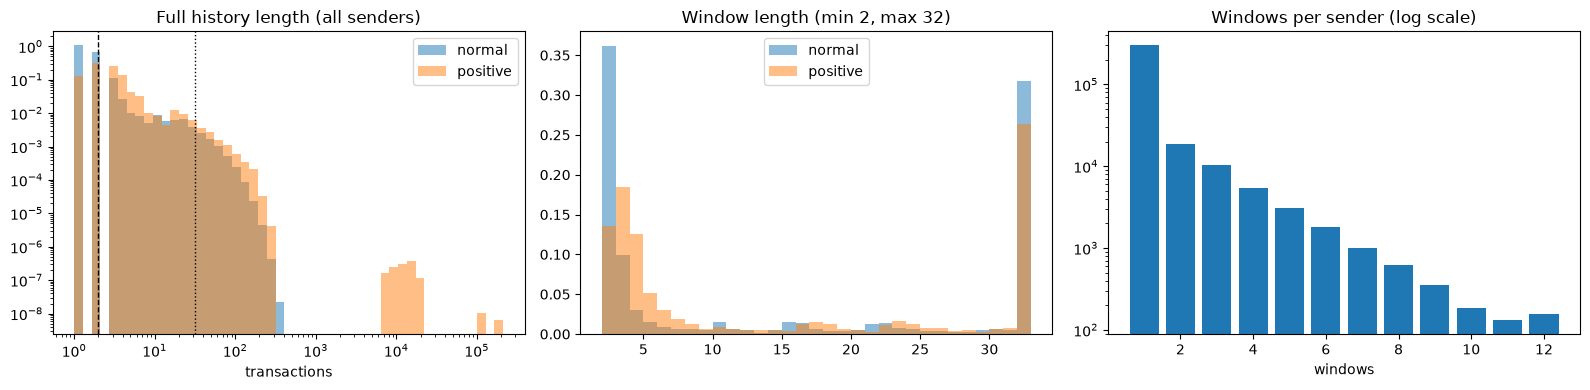

In [79]:
# --- 7.2 Class balance per split (senders and windows)
def balance(s_mask, w_mask):
    return {"senders": int(s_mask.sum()), "positive senders": int(senders.loc[s_mask, "label"].sum()),
            "positive sender rate": float(senders.loc[s_mask, "label"].mean()),
            "windows": int(w_mask.sum()), "positive windows": int(seqs.loc[w_mask, "label"].sum()),
            "positive window rate": float(seqs.loc[w_mask, "label"].mean()),
            "senders with tail": int(senders.loc[s_mask, "has_tail"].sum())}
bal = pd.DataFrame({
    "train": balance(senders.split == "train", seqs.split == "train"),
    "train (used)": balance(senders.train_keep, seqs.train_keep),
    "val": balance(senders.split == "val", seqs.split == "val"),
    "test": balance(senders.split == "test", seqs.split == "test"),
}).T
display(bal)

# --- 7.3 Sequence length distribution
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
bins_full = np.logspace(0, np.log10(sender_ntx.max()) + 0.1, 50)
ax[0].hist(sender_ntx[sender_ever == 0], bins=bins_full, alpha=0.5, density=True, label="normal")
ax[0].hist(sender_ntx[sender_ever == 1], bins=bins_full, alpha=0.5, density=True, label="positive")
ax[0].axvline(MIN_LEN, color="k", ls="--", lw=1); ax[0].axvline(MAX_LEN, color="k", ls=":", lw=1)
ax[0].set_xscale("log"); ax[0].set_yscale("log"); ax[0].legend()
ax[0].set_title("Full history length (all senders)"); ax[0].set_xlabel("transactions")

bins_w = np.arange(MIN_LEN, MAX_LEN + 2)
ax[1].hist(seqs.loc[seqs.label == 0, "length"], bins=bins_w, alpha=0.5, density=True, label="normal")
ax[1].hist(seqs.loc[seqs.label == 1, "length"], bins=bins_w, alpha=0.5, density=True, label="positive")
ax[1].set_title(f"Window length (min {MIN_LEN}, max {MAX_LEN})"); ax[1].legend()

wc = senders["n_windows"].value_counts().sort_index()
ax[2].bar(wc.index, wc.values); ax[2].set_yscale("log")
ax[2].set_title("Windows per sender (log scale)"); ax[2].set_xlabel("windows")
plt.tight_layout(); plt.show()

**Hallazgos**

- Todos los chequeos del pipeline pasan: ningún emisor en dos splits, el padding es cero, las etiquetas calzan
  con el lavado dentro de cada ventana, las transacciones están en orden temporal y los features continuos están
  estandarizados.
- Las ventanas positivas son más cortas que las normales (la mayoría de emisores positivos tiene poca historia),
  lo cual importa para Stage A (Parte 14).

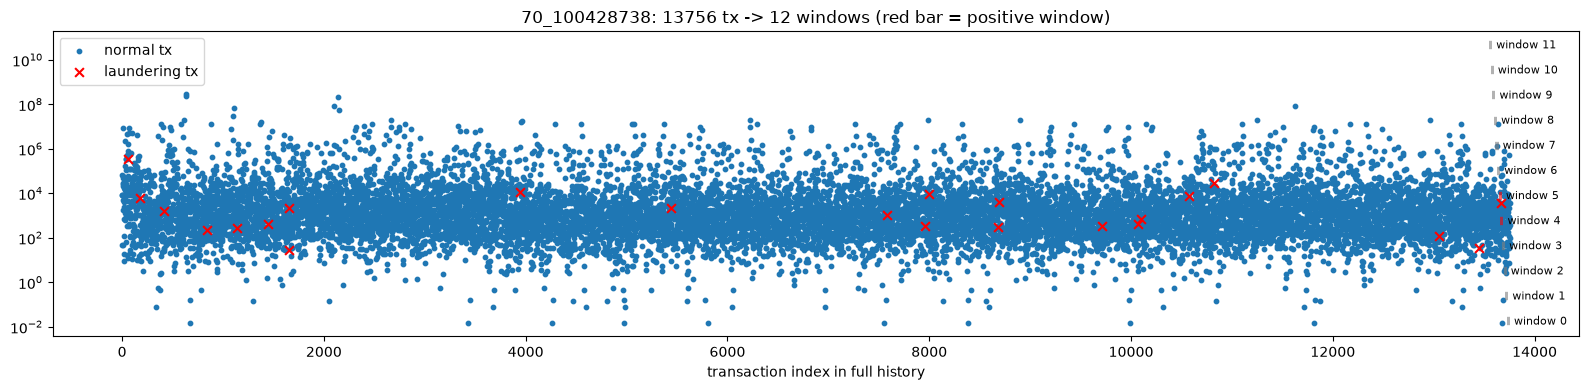

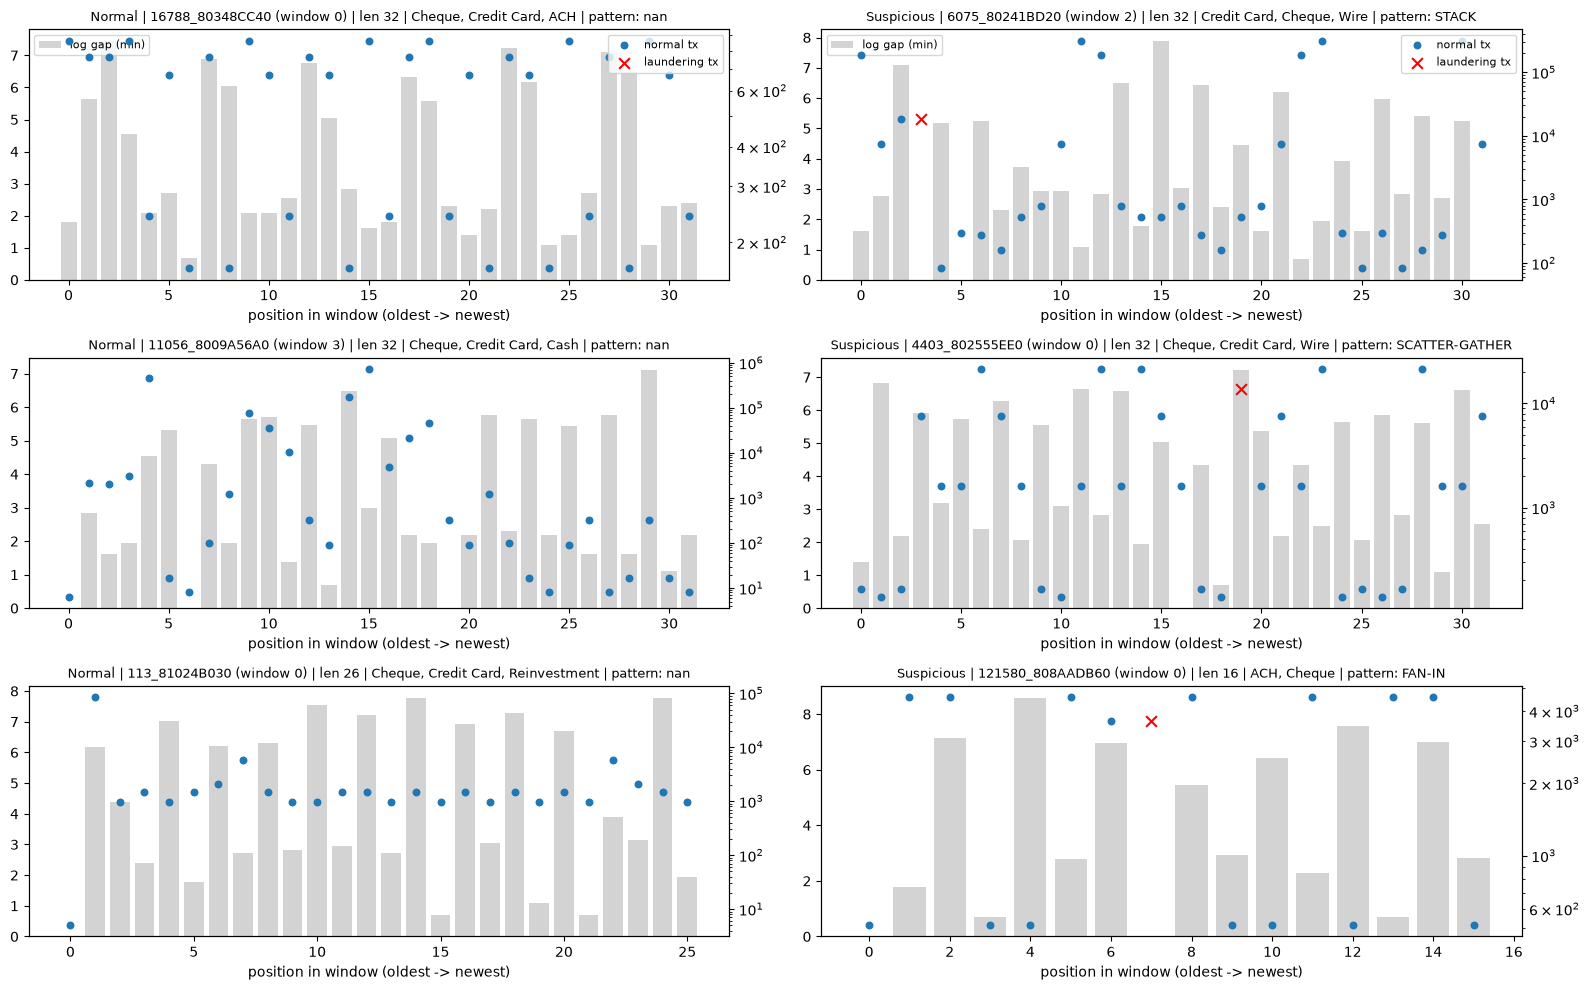

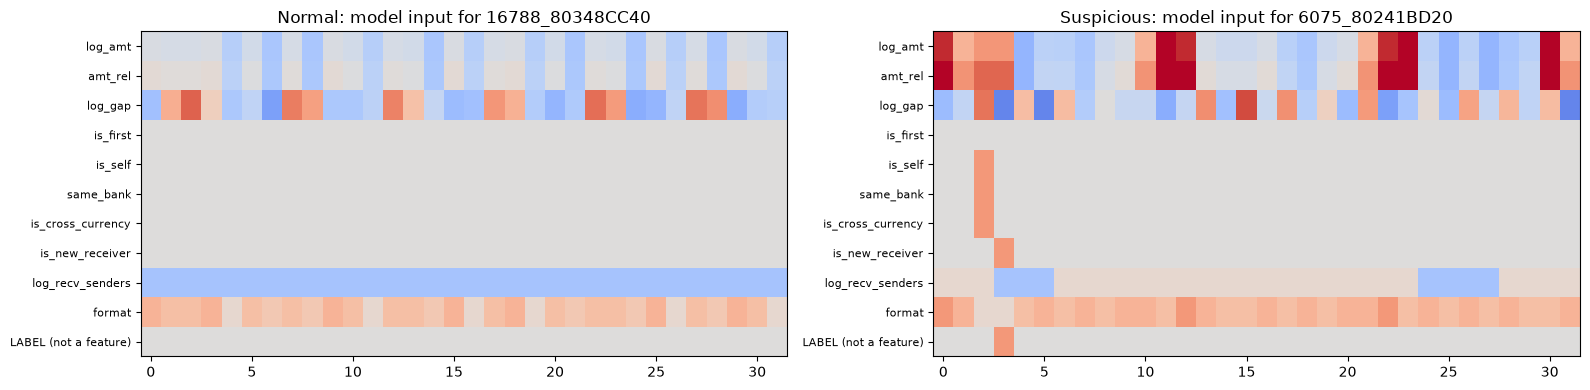

In [80]:
# --- 7.4 How sliding windows cover a long sender's history
cand = senders[(senders.n_windows >= 3)].sort_values(["label", "n_windows"], ascending=False)
if len(cand):
    sid = int(cand.index[0])
    k = int(np.flatnonzero(sender_ntx.index.to_numpy() == sid)[0])
    hist_rows = df.iloc[offsets[k]:offsets[k] + counts[k]]
    fig, ax = plt.subplots(figsize=(16, 4))
    bad = hist_rows["is_laundering"].to_numpy() == 1
    x = np.arange(len(hist_rows))
    ax.scatter(x[~bad], hist_rows["amt_usd"].to_numpy()[~bad], s=10, label="normal tx")
    ax.scatter(x[bad], hist_rows["amt_usd"].to_numpy()[bad], s=40, c="red", marker="x", label="laundering tx")
    ax.set_yscale("log")
    ymin, ymax = ax.get_ylim()
    for _, win in seqs[seqs.sender == sid].iterrows():
        y = ymin * (ymax / ymin) ** (0.05 + 0.1 * win.win_rank)
        ax.hlines(y, win.win_start, win.win_start + win.length - 1, lw=6, alpha=0.6,
                  color="red" if win.label else "gray")
        ax.text(win.win_start + win.length, y, f" window {win.win_rank}", va="center", fontsize=8)
    ax.set_title(f"{senders.loc[sid, 'sender_name']}: {counts[k]} tx -> {senders.loc[sid, 'n_windows']} windows "
                 f"(red bar = positive window)")
    ax.set_xlabel("transaction index in full history"); ax.legend(loc="upper left")
    plt.tight_layout(); plt.show()

# --- 7.5 Example sequences: 3 normal vs 3 suspicious windows (raw values, before normalization)
rng = np.random.default_rng(SEED)
def pick(label, k=3, min_len=15):
    cand = seqs[(seqs.label == label) & (seqs.length >= min_len)].index.to_numpy()
    if len(cand) < k:
        cand = seqs[seqs.label == label].index.to_numpy()
    return rng.choice(cand, size=min(k, len(cand)), replace=False)

examples = {"Normal": pick(0), "Suspicious": pick(1)}
fig, axes = plt.subplots(3, 2, figsize=(16, 10), squeeze=False)
for col, (kind, ids) in enumerate(examples.items()):
    for row in range(3):
        ax = axes[row, col]
        if row >= len(ids):
            ax.axis("off"); continue
        s = w[w["seq"] == ids[row]]
        bad = s["is_laundering"] == 1
        ax.bar(s["pos"], s["log_gap"], color="lightgray", label="log gap (min)")
        ax2 = ax.twinx()
        ax2.scatter(s.loc[~bad, "pos"], s.loc[~bad, "amt_usd"], s=22, label="normal tx")
        ax2.scatter(s.loc[bad, "pos"], s.loc[bad, "amt_usd"], s=60, c="red", marker="x", label="laundering tx")
        ax2.set_yscale("log")
        meta = seqs.loc[ids[row]]
        fmts = ", ".join(s["pay_format"].astype(str).value_counts().index[:3])
        ax.set_title(f"{kind} | {meta.sender_name} (window {meta.win_rank}) | len {meta.length} | {fmts} | "
                     f"pattern: {meta.pattern}", fontsize=9)
        ax.set_xlabel("position in window (oldest -> newest)")
        if row == 0:
            ax.legend(loc="upper left", fontsize=8); ax2.legend(loc="upper right", fontsize=8)
plt.tight_layout(); plt.show()

# feature matrix view (what the model actually sees), one normal and one suspicious
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
for ax, (kind, ids) in zip(axes, examples.items()):
    i = ids[0]; n_i = int(MASK[i].sum())
    mat = np.vstack([X_num[i, :n_i].T, X_fmt[i, :n_i] / len(FMT_NAMES), Y_TX[i, :n_i]])
    ax.imshow(mat, aspect="auto", cmap="coolwarm", vmin=-2, vmax=2)
    ax.set_yticks(range(len(NUM_FEATURES) + 2))
    ax.set_yticklabels(NUM_FEATURES + ["format", "LABEL (not a feature)"], fontsize=8)
    ax.set_title(f"{kind}: model input for {seqs.loc[i, 'sender_name']}")
plt.tight_layout(); plt.show()

**Hallazgos**

- Basados en la primera imagen podemos deducir que el monto de la transacción no es un buen separador de transacciones legítimas
    vs fraude.
- Basados en la segunda imagen, los patrones de transacciones normales tienden a ser relativamente regulares. Podemos darnos cuenta también que las
    transacciones fraudulentas tienden a tener gaps muy grandes o pequeños.
- Basados en la tercera imagen, la señal está en la secuencia y no en transacciones aisladas. La transacción fraudulenta aparece justo
    después de una auto-transferencia con cambio de moneda y va dirigida a un receptor nuevo con pocos remitentes, mientras que los
    montos altos (`amt_rel`) no coinciden con la etiqueta de lavado.

### Guardar datos procesados

In [81]:
def save_table(frame, name):
    try:
        frame.to_parquet(os.path.join(OUT_DIR, name + ".parquet"), index=False)
    except ImportError:
        frame.to_csv(os.path.join(OUT_DIR, name + ".csv"), index=False)

np.save(os.path.join(OUT_DIR, "X_num.npy"), X_num)
np.save(os.path.join(OUT_DIR, "X_fmt.npy"), X_fmt)
np.save(os.path.join(OUT_DIR, "X_cur.npy"), X_cur)
np.save(os.path.join(OUT_DIR, "MASK.npy"), MASK)
np.save(os.path.join(OUT_DIR, "Y_TX.npy"), Y_TX)
np.save(os.path.join(OUT_DIR, "TX_ID.npy"), TX_ID)
save_table(seqs.reset_index(), "windows")
save_table(senders.reset_index(), "senders")

# readable transactions for val/test windows (needed later for interpretability and the MVP)
eval_seq = seqs.index[seqs["split"].isin(["val", "test"])]
tx_view = w[w["seq"].isin(eval_seq)].copy()
tx_view["receiver_name"] = ACCOUNT_NAMES[tx_view["receiver"].to_numpy()]
tx_view["pay_format"] = tx_view["pay_format"].astype(str)
tx_view["pay_currency"] = tx_view["pay_currency"].astype(str)
save_table(tx_view[["seq", "pos", "sender", "tx_id", "ts", "receiver_name", "amt_usd", "pay_format",
                    "pay_currency", "is_laundering", "pattern", "is_tail"]], "eval_transactions")

META = {"NUM_FEATURES": NUM_FEATURES, "CONT_FEATURES": CONT_FEATURES, "NORM": NORM,
        "FMT_NAMES": FMT_NAMES, "CUR_NAMES": CUR_NAMES,
        "config": {"SEED": SEED, "MAX_LEN": MAX_LEN, "STRIDE": STRIDE,
                   "MAX_WINDOWS_PER_SENDER": MAX_WINDOWS_PER_SENDER, "MIN_LEN": MIN_LEN,
                   "TAIL_START": TAIL_START, "WR_FORMATS": WR_FORMATS,
                   "WR_ONLY_KEEP_FRAC": WR_ONLY_KEEP_FRAC, "SPLIT_FRACS": SPLIT_FRACS},
        "rates_to_usd": {k: float(v) for k, v in rates.items()}}
with open(os.path.join(OUT_DIR, "meta.json"), "w") as f:
    json.dump(META, f, indent=2)

# free the transaction tables; everything below uses the arrays + seqs/senders
del df, w, tx_view, rows, rep, pos
gc.collect()
print(sorted(os.listdir(OUT_DIR)), elapsed())

['MASK.npy', 'TX_ID.npy', 'X_cur.npy', 'X_fmt.npy', 'X_num.npy', 'Y_TX.npy', 'ablation_results.csv', 'eval_transactions.parquet', 'final_system.json', 'final_test_senders.parquet', 'idx_stage_a_train.npy', 'idx_stage_b_train.npy', 'idx_test.npy', 'idx_val.npy', 'meta.json', 'poolw_a.npy', 'senders.parquet', 'stage_a.pt', 'stage_a_history.csv', 'stage_a_scoring_candidates.csv', 'stage_b.pt', 'stage_b_test_attention.npy', 'txerr_a.npy', 'window_score_a.npy', 'windows.parquet'] [98.3 min]


## 13. Métricas de Evaluación

Antes de modelar, las métricas. Menos del 1% de emisores son positivos, así que un modelo que nunca alerta tiene
99% de accuracy y es completamente inútil. Lo que le importa a un equipo de cumplimiento es: **si solo podemos
revisar un número limitado de alertas, cuántos casos reales hay ahí, y cuántos casos se nos escapan?**

Todo se evalúa **por emisor** (la unidad que recibe una alerta), nunca por ventana, porque ventanas solapadas del
mismo emisor no son independientes.

| Métrica | Qué pregunta responde | Rol |
|---|---|---|
| **PR-AUC** (average precision) | Qué tan buena es toda la ranking de emisores poniendo positivos primero? | **Métrica principal.** La selección de modelo se hace con esto en validación. Un ranking aleatorio da la tasa positiva (~0.0094), así que también reportamos el lift sobre aleatorio. |
| **Recall @ 1% y @ 5% de emisores alertados** | Si el equipo revisa el 1% (≈516) o 5% (≈2,580) más riesgoso, qué fracción de lavadores encuentran? | **Métrica operativa.** Se traduce directo a carga de trabajo para el reporte. |
| **Precision @ 100** | De las top 100 alertas, cuántas son reales? | Vista de cola de un analista. Sistemas basados en reglas corren a 1–5% de precision (95–99% falsos positivos, según el enunciado). |
| Precision / recall / F1 en un umbral | Qué pasa en un corte concreto, elegido en validación (mejor F1)? | Necesario para desplegar, pero depende del umbral elegido. |
| ROC-AUC | Probabilidad de que un positivo aleatorio quede rankeado sobre un negativo aleatorio | Se muestra por completitud; se ve bien incluso para modelos débiles cuando dominan los negativos. |

Los números de test vienen con **intervalos bootstrap del 95%** (resampleando emisores de test), para no leer
ruido como progreso.

In [82]:
def average_precision(y, s):
    o = np.argsort(-s, kind="mergesort"); ys = y[o]
    precision = np.cumsum(ys) / np.arange(1, len(ys) + 1)
    return float((precision * ys).sum() / max(ys.sum(), 1))

def roc_auc(y, s):
    ranks = pd.Series(s).rank().to_numpy(); n1 = y.sum(); n0 = len(y) - n1
    return float((ranks[y == 1].sum() - n1 * (n1 + 1) / 2) / max(n1 * n0, 1))

def recall_at_budget(y, s, frac):
    k = max(1, int(round(len(y) * frac))); o = np.argsort(-s, kind="mergesort")
    return float(y[o[:k]].sum() / max(y.sum(), 1))

def precision_at_k(y, s, k=100):
    o = np.argsort(-s, kind="mergesort")
    return float(y[o[:k]].mean())

def best_f1_threshold(y, s):
    o = np.argsort(-s, kind="mergesort"); ys, ss = y[o], s[o]
    tp = np.cumsum(ys); k = np.arange(1, len(ys) + 1)
    prec, rec = tp / k, tp / max(ys.sum(), 1)
    f1 = 2 * prec * rec / np.maximum(prec + rec, 1e-12)
    return float(ss[int(f1.argmax())])

def evaluate(y, s, thr=None):
    y = np.asarray(y).astype(np.int64); s = np.asarray(s, dtype=np.float64)
    out = {"PR-AUC": average_precision(y, s)}
    out["lift vs random"] = out["PR-AUC"] / max(y.mean(), 1e-12)
    out.update({"ROC-AUC": roc_auc(y, s), "P@100": precision_at_k(y, s, 100),
                "recall @1%": recall_at_budget(y, s, 0.01), "recall @5%": recall_at_budget(y, s, 0.05)})
    if thr is not None:
        pred = s >= thr; tp = int((pred & (y == 1)).sum())
        p, r = tp / max(pred.sum(), 1), tp / max(y.sum(), 1)
        out.update({"precision @thr": p, "recall @thr": r, "F1 @thr": 2 * p * r / max(p + r, 1e-12),
                    "alert rate @thr": float(pred.mean())})
    return out

def bootstrap_ci(y, s, fn, n_boot=200, seed=SEED):
    rng = np.random.default_rng(seed); y = np.asarray(y); s = np.asarray(s, dtype=np.float64)
    vals = [fn(y[i], s[i]) for i in (rng.integers(0, len(y), len(y)) for _ in range(n_boot))]
    return float(np.percentile(vals, 2.5)), float(np.percentile(vals, 97.5))

# sender-level view of any per-window score
SENDER_OF = seqs["sender"].to_numpy()
LEN = MASK.sum(1)
def to_senders(window_scores, idx, agg="max"):
    """window_scores covers ALL windows (global index); idx selects the windows to aggregate."""
    return pd.Series(np.asarray(window_scores)[idx], index=SENDER_OF[idx]).groupby(level=0).agg(agg)

def local_to_senders(values, idx, agg="max"):
    """values[i] belongs to window idx[i] (e.g. predictions made only on the validation windows)."""
    return pd.Series(np.asarray(values), index=SENDER_OF[idx]).groupby(level=0).agg(agg)

VAL_SENDERS = np.unique(SENDER_OF[SETS["val"]])
TEST_SENDERS = np.unique(SENDER_OF[SETS["test"]])
Y_VAL = senders.loc[VAL_SENDERS, "label"].to_numpy()
Y_TEST = senders.loc[TEST_SENDERS, "label"].to_numpy()
print(f"Validation: {len(VAL_SENDERS):,} senders ({Y_VAL.sum()} positive) | "
      f"test: {len(TEST_SENDERS):,} senders ({Y_TEST.sum()} positive)")

Validation: 51,637 senders (487 positive) | test: 51,637 senders (486 positive)
